In [1]:
import os
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter

# Single folder contains BOTH images and XMLs
TRAIN_DIR = "/kaggle/input/datasets/carltonayebare1738/gas-leak-images/train"
VALID_DIR = "/kaggle/input/datasets/carltonayebare1738/gas-leak-images/valid"

# Parse one XML to understand structure
xml_files = [f for f in os.listdir(TRAIN_DIR) if f.endswith(".xml")]
sample_xml = os.path.join(TRAIN_DIR, xml_files[0])

tree = ET.parse(sample_xml)
root = tree.getroot()

print("Filename:", root.find("filename").text)
print("Width:",    root.find("size/width").text)
print("Height:",   root.find("size/height").text)
for obj in root.findall("object"):
    print("Class:", obj.find("name").text)
    b = obj.find("bndbox")
    print("  BBox:", b.find("xmin").text, b.find("ymin").text,
                     b.find("xmax").text, b.find("ymax").text)

Filename: frames1_000166_jpg.rf.dfa0e7325438fc279225ba2a3f0837ec.jpg
Width: 720
Height: 1280
Class: leak
  BBox: 79 412 611 1118


In [2]:
# Count classes — scan only XML files in the folder
all_classes = []
for fname in os.listdir(TRAIN_DIR):
    if not fname.endswith(".xml"):
        continue
    tree = ET.parse(os.path.join(TRAIN_DIR, fname))
    root = tree.getroot()
    for obj in root.findall("object"):
        all_classes.append(obj.find("name").text)

class_counts = Counter(all_classes)
print("Classes:", class_counts)

Classes: Counter({'leak': 9153})


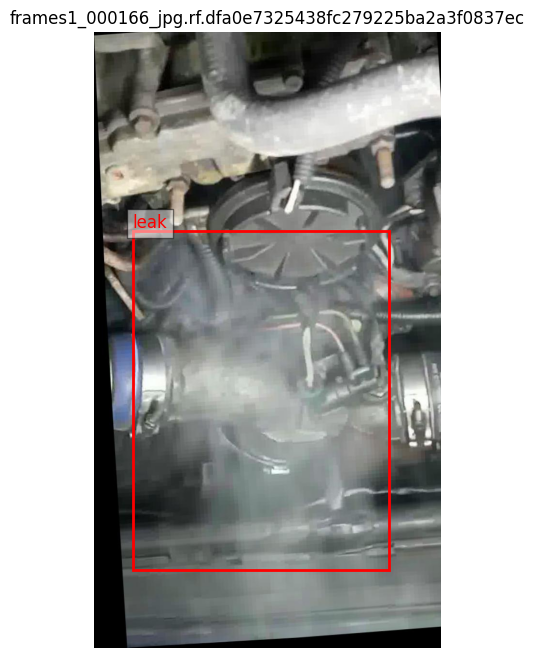

In [3]:
# Visualize image + bounding boxes — image and XML are in the SAME folder
def show_image_with_boxes(folder, filename_no_ext):
    # Try both .jpg and .png
    for ext in [".jpg", ".jpeg", ".png"]:
        img_path = os.path.join(folder, filename_no_ext + ext)
        if os.path.exists(img_path):
            break

    xml_path = os.path.join(folder, filename_no_ext + ".xml")

    img  = Image.open(img_path)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)
    for obj in root.findall("object"):
        label = obj.find("name").text
        b     = obj.find("bndbox")
        xmin, ymin = int(b.find("xmin").text), int(b.find("ymin").text)
        xmax, ymax = int(b.find("xmax").text), int(b.find("ymax").text)
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                  linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, label, color='red', fontsize=12,
                bbox=dict(facecolor='white', alpha=0.5))
    plt.title(filename_no_ext)
    plt.axis('off')
    plt.show()

# Call with any sample (strip the .xml extension)
sample = xml_files[0].replace(".xml", "")
show_image_with_boxes(TRAIN_DIR, sample)

In [4]:
import shutil

def convert_and_split(source_dir, out_img_dir, out_lbl_dir, class_list):
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    xml_files = [f for f in os.listdir(source_dir) if f.endswith(".xml")]

    for xml_file in xml_files:
        stem = xml_file.replace(".xml", "")
        xml_path = os.path.join(source_dir, xml_file)

        # --- Copy the image ---
        copied = False
        for ext in [".jpg", ".jpeg", ".png"]:
            src_img = os.path.join(source_dir, stem + ext)
            if os.path.exists(src_img):
                shutil.copy(src_img, os.path.join(out_img_dir, stem + ext))
                copied = True
                break
        if not copied:
            print(f"WARNING: No image found for {stem}")
            continue

        # --- Convert XML to YOLO label ---
        tree = ET.parse(xml_path)
        root = tree.getroot()
        W = int(root.find("size/width").text)
        H = int(root.find("size/height").text)

        lines = []
        for obj in root.findall("object"):
            cls = obj.find("name").text
            if cls not in class_list:
                continue
            cls_id = class_list.index(cls)
            b    = obj.find("bndbox")
            xmin = int(b.find("xmin").text)
            ymin = int(b.find("ymin").text)
            xmax = int(b.find("xmax").text)
            ymax = int(b.find("ymax").text)
            cx = ((xmin + xmax) / 2) / W
            cy = ((ymin + ymax) / 2) / H
            w  = (xmax - xmin) / W
            h  = (ymax - ymin) / H
            lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

        lbl_path = os.path.join(out_lbl_dir, stem + ".txt")
        with open(lbl_path, "w") as f:
            f.write("\n".join(lines))

    print(f"Done: {len(xml_files)} files processed from {source_dir}")


class_list = list(class_counts.keys())  # from contextualizing step

# Convert train
convert_and_split(
    TRAIN_DIR,
    "/kaggle/working/images/train",
    "/kaggle/working/labels/train",
    class_list
)

# Convert valid
convert_and_split(
    VALID_DIR,
    "/kaggle/working/images/valid",
    "/kaggle/working/labels/valid",
    class_list
)

Done: 8660 files processed from /kaggle/input/datasets/carltonayebare1738/gas-leak-images/train
Done: 221 files processed from /kaggle/input/datasets/carltonayebare1738/gas-leak-images/valid


In [17]:
import os

# First, confirm your class list is still in memory
# If you restarted the kernel, redefine it manually based on your dataset
print("Current class_list:", class_list)

Current class_list: ['leak']


In [19]:
yaml_content = f"""train: /kaggle/working/images/train
val: /kaggle/working/images/valid

nc: {len(class_list)}
names: {class_list}
"""

# Write it
with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)

# Immediately read it back to confirm it saved
with open("/kaggle/working/data.yaml", "r") as f:
    content = f.read()

print("=== data.yaml contents ===")
print(content)
print(f"File size: {os.path.getsize('/kaggle/working/data.yaml')} bytes")

=== data.yaml contents ===
train: /kaggle/working/images/train
val: /kaggle/working/images/valid

nc: 1
names: ['leak']

File size: 93 bytes


In [20]:
dirs_to_check = [
    "/kaggle/working/images/train",
    "/kaggle/working/images/valid",
    "/kaggle/working/labels/train",
    "/kaggle/working/labels/valid"
]

all_good = True
for d in dirs_to_check:
    if os.path.exists(d):
        count = len(os.listdir(d))
        print(f"✅ {d}  —  {count} files")
        if count == 0:
            print(f"   ⚠️  WARNING: folder is empty!")
            all_good = False
    else:
        print(f"❌ MISSING: {d}")
        all_good = False

if all_good:
    print("\n✅ All folders present and populated — safe to train")
else:
    print("\n❌ Fix the missing/empty folders before training")

✅ /kaggle/working/images/train  —  8660 files
✅ /kaggle/working/images/valid  —  221 files
✅ /kaggle/working/labels/train  —  8660 files
✅ /kaggle/working/labels/valid  —  221 files

✅ All folders present and populated — safe to train


In [1]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="yolov8_experiment",
    project="/kaggle/working/runs",
    pretrained=True,
    optimizer="AdamW",
    lr0=0.001,
    plots=True,
    save=True,
    save_period=1,
    exist_ok=True
)

ModuleNotFoundError: No module named 'ultralytics'

In [2]:
!pip install ultralytics grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 90.4 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.6 MB/s eta 0:00:00


In [18]:
class_list = ["leak"]

In [6]:
import os, shutil, xml.etree.ElementTree as ET
from collections import Counter

TRAIN_DIR = "/kaggle/input/your-dataset/train"   # your actual input path
VALID_DIR = "/kaggle/input/your-dataset/valid"

def convert_and_split(source_dir, out_img_dir, out_lbl_dir, class_list):
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)
    xml_files = [f for f in os.listdir(source_dir) if f.endswith(".xml")]
    for xml_file in xml_files:
        stem = xml_file.replace(".xml", "")
        xml_path = os.path.join(source_dir, xml_file)
        copied = False
        for ext in [".jpg", ".jpeg", ".png"]:
            src_img = os.path.join(source_dir, stem + ext)
            if os.path.exists(src_img):
                shutil.copy(src_img, os.path.join(out_img_dir, stem + ext))
                copied = True
                break
        if not copied:
            continue
        tree = ET.parse(xml_path)
        root = tree.getroot()
        W = int(root.find("size/width").text)
        H = int(root.find("size/height").text)
        lines = []
        for obj in root.findall("object"):
            cls = obj.find("name").text
            if cls not in class_list:
                continue
            cls_id = class_list.index(cls)
            b = obj.find("bndbox")
            xmin, ymin = int(b.find("xmin").text), int(b.find("ymin").text)
            xmax, ymax = int(b.find("xmax").text), int(b.find("ymax").text)
            cx = ((xmin + xmax) / 2) / W
            cy = ((ymin + ymax) / 2) / H
            w  = (xmax - xmin) / W
            h  = (ymax - ymin) / H
            lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
        with open(os.path.join(out_lbl_dir, stem + ".txt"), "w") as f:
            f.write("\n".join(lines))
    print(f"✅ Done: {len(xml_files)} files from {source_dir}")

convert_and_split(TRAIN_DIR, "/kaggle/working/images/train", "/kaggle/working/labels/train", class_list)
convert_and_split(VALID_DIR, "/kaggle/working/images/valid", "/kaggle/working/labels/valid", class_list)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/your-dataset/train'

In [6]:
# Install
!pip install ultralytics -q

from ultralytics import YOLO

# Load a pretrained YOLOv8 model (transfer learning)
model = YOLO("yolov8m.pt")  # m = medium. Options: n, s, m, l, x

# Train
results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="yolov8_experiment",
    project="/kaggle/working/runs",
    pretrained=True,
    optimizer="AdamW",
    lr0=0.001,
    plots=True,         # auto-generates training plots
    save=True
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_experiment2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, p

RuntimeError: Dataset '/kaggle/working/data.yaml' error ❌ '/kaggle/working/data.yaml' does not exist

In [7]:
# Print the model architecture
from ultralytics import YOLO
model = YOLO("yolov8m.pt")
print(model.model)

# Count parameters
total_params = sum(p.numel() for p in model.model.parameters())
print(f"Total parameters: {total_params:,}")

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
   

In [8]:
# Option 1: Use torchviz
!pip install torchviz -q
from torchviz import make_dot
import torch

dummy_input = torch.zeros(1, 3, 640, 640)
# YOLOv8 uses a custom forward — use Netron instead for cleaner viz

# Option 2 (BEST): Export to ONNX and open in Netron
model.export(format="onnx")
# Then download the .onnx file and open at https://netron.app

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8m summary (fused): 92 layers, 25,886,080 parameters, 0 gradients, 78.9 GFLOPs

PyTorch: starting from 'yolov8m.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (49.7 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 252ms
Prepared 2 packages in 2.62s
Installed 2 packages in 12ms
 + onnxruntime-gpu==1.24.3
 + onnxslim==0.1.87

requirements: AutoUpdate success ✅ 3.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 22...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 6.7s, saved as 'yolov8m.onnx' (99.0 MB)

Export complete (8.5s)
Results saved to /kaggle/working
Predict:         yolo predict task=detect model=yolov8m.onnx imgsz=640 
Validate:        yolo val task=detect model=yolov8m.onnx imgsz=640 data=coco.yaml  
Visualize:       https://netron.app


'yolov8m.onnx'

Using image: /kaggle/working/images/train/3_jpg.rf.40b24170d90aabfa4b610d476a7e5a3f.jpg
Feature map shape: torch.Size([48, 320, 320])


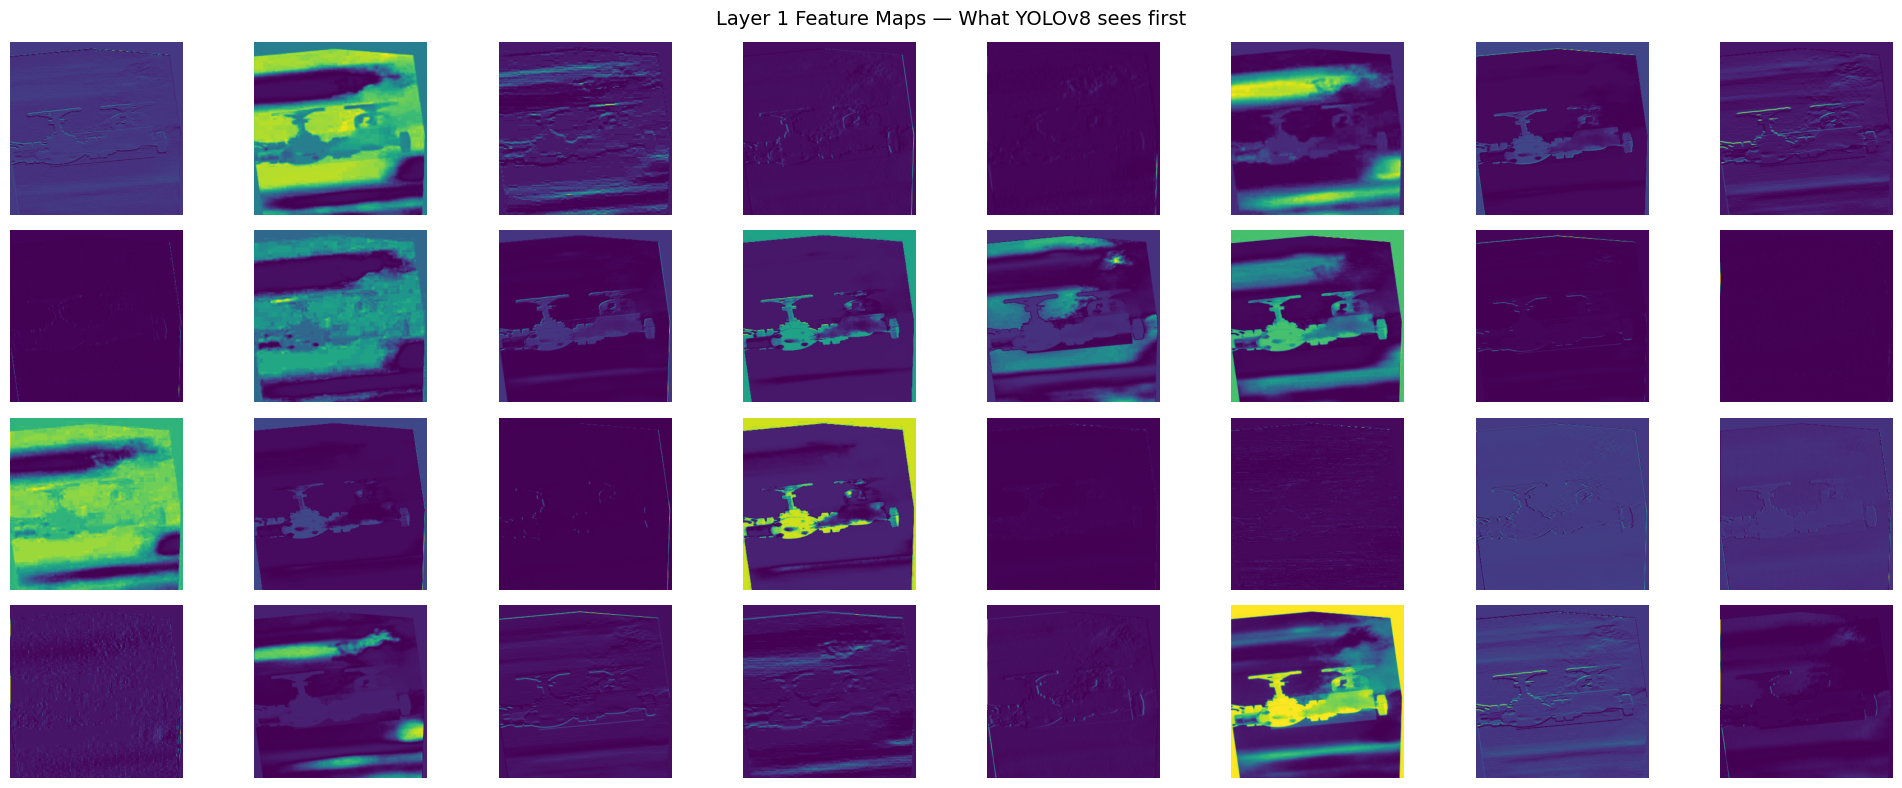

In [10]:
import torch
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

# --- Auto-pick a real image ---
img_dir = "/kaggle/working/images/train"
all_images = [f for f in os.listdir(img_dir) if f.endswith((".jpg", ".jpeg", ".png"))]
sample_img_path = os.path.join(img_dir, all_images[0])
print("Using image:", sample_img_path)

# --- Load and prepare tensor ---
img = Image.open(sample_img_path).resize((640, 640)).convert("RGB")
tensor = T.ToTensor()(img).unsqueeze(0)  # shape: (1, 3, 640, 640)

# --- Hook into first Conv layer ---
activations = {}
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

hook_handle = list(model.model.model.children())[0].register_forward_hook(get_activation("conv1"))

with torch.no_grad():
    model.model(tensor)

hook_handle.remove()  # always clean up hooks

# --- Plot feature maps ---
feat = activations["conv1"].squeeze(0)
print(f"Feature map shape: {feat.shape}")  # (channels, H, W)

fig, axes = plt.subplots(4, 8, figsize=(20, 8))
for i, ax in enumerate(axes.flat):
    if i < feat.shape[0]:
        ax.imshow(feat[i].cpu(), cmap='viridis')
    ax.axis('off')
plt.suptitle("Layer 1 Feature Maps — What YOLOv8 sees first", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [16]:
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt

# --- Wrapper to make YOLOv8 compatible with GradCAM ---
class YOLOv8GradCAMWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        output = self.model(x)
        # YOLOv8 returns a tuple — extract the prediction tensor
        if isinstance(output, (tuple, list)):
            output = output[0]
        # output shape is (batch, num_boxes, classes+4)
        # Return max confidence score across all boxes as a 2D tensor
        if output.ndim == 3:
            output = output[:, :, 4:].max(dim=1)[0]  # (batch, num_classes)
        return output

# --- Load your trained model ---
from ultralytics import YOLO
yolo = YOLO("/kaggle/working/runs/yolov8_experiment/weights/best.pt")
yolo.model.eval()

wrapped_model = YOLOv8GradCAMWrapper(yolo.model)

# --- Pick target layer (last backbone layer) ---
# This finds the last Conv2d layer automatically
target_layers = []
for name, module in yolo.model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        target_layers = [module]  # keeps updating — ends on the last one
print("Target layer:", target_layers[0])

# --- Prepare image ---
img_dir = "/kaggle/working/images/train"
all_images = [f for f in os.listdir(img_dir) if f.endswith((".jpg", ".jpeg", ".png"))]
img_path = os.path.join(img_dir, all_images[0])
print("Using image:", img_path)

img_bgr     = cv2.imread(img_path)
img_rgb     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (640, 640))
tensor      = torch.from_numpy(img_resized).permute(2, 0, 1).float().unsqueeze(0) / 255.0

# --- Run EigenCAM ---
cam           = EigenCAM(wrapped_model, target_layers)
grayscale_cam = cam(input_tensor=tensor)[0]
visualization = show_cam_on_image(img_resized / 255.0, grayscale_cam, use_rgb=True)

# --- Plot ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_resized)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(grayscale_cam, cmap='jet')
plt.title("Raw GradCAM Heatmap")
plt.colorbar()
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(visualization)
plt.title("GradCAM Overlay — Model Attention")
plt.axis('off')

plt.suptitle("Where YOLOv8 focuses its attention", fontsize=14)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/runs/yolov8_experiment/weights/best.pt'